# Problem 1

Consider the lung cancer data and solve the following questions using Python:

---

## Basic EDA Questions

1. Summarize the distribution of Age. Is it normally distributed or skewed?

2. What proportion of individuals are smokers vs non-smokers?

3. Which income group has the highest frequency?

4. What percentage of individuals are exposed to high pollution?

5. What is the overall prevalence of lung disease?

---

## Association & Crosstab

1. Is there an association between Smoking and Lung Disease?

2. Interpret using a contingency table.

---

## Does Pollution Level Affect Lung Disease?

1. Compare lung disease prevalence across income groups.

2. Which factor appears to have the strongest relationship with lung disease?

---

## Statistical Testing

1. Perform a Chi-square test for:
   - Smoking vs Lung Disease
   - Pollution vs Lung Disease

2. When should you use Fisher’s Exact Test instead of Chi-square?

3. Calculate and interpret the Odds Ratio for Smoking and Lung Disease.

---

## Correlation & Interpretation

1. Interpret the correlation between:
   - Smoking and Lung Disease
   - Age and Lung Disease

2. Why is correlation not sufficient for causal inference?

---

## Logistic Regression

1. Fit a logistic regression model:

\[
{LungDisease} ~ {Smoking} + {Age} + \{Pollution} + {Income}
\]

2. Which variables are statistically significant predictors?

3. Interpret the odds ratio of Smoking.

4. What happens to the effect of Smoking after adjusting for Pollution?

---

## Advanced Modeling

1. Add an interaction term:

\[
{Smoking} X {Pollution}
\]

2. Is the interaction significant?

3. Interpret the interaction.

4. Does pollution amplify smoking risk?

---

## Model Evaluation

1. Compute the ROC curve and AUC.

2. Is the model good?

3. What is the confusion matrix?

4. Discuss model accuracy vs sensitivity vs specificity.

---

## Research Question

> “Using the lung disease dataset, perform exploratory data analysis and fit a logistic regression model to identify key determinants of lung disease. Interpret your findings and discuss public health implications.”

## Basic EDA Questions

1. Summarize the distribution of Age. Is it normally distributed or skewed?

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro

In [3]:
df = pd.read_csv("/content/lung_disease.csv")

In [4]:
print(df.head())

   ID Smoking  Age  Income Pollution LungDisease
0   1     Yes   36     Low      High         Yes
1   2      No   28     Low       Low          No
2   3      No   52  Medium      High          No
3   4      No   39    High      High          No
4   5     Yes   32     Low       Low         Yes


In [5]:
# Summary statistics

print(df['Age'].describe())

count    500.000000
mean      43.904000
std       14.604841
min       20.000000
25%       30.750000
50%       45.000000
75%       56.000000
max       69.000000
Name: Age, dtype: float64


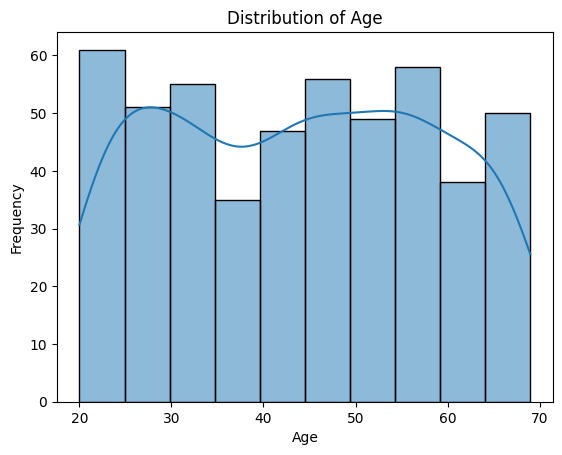

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df['Age'],
    kde=True,
    bins=10
)

plt.title("Distribution of Age")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

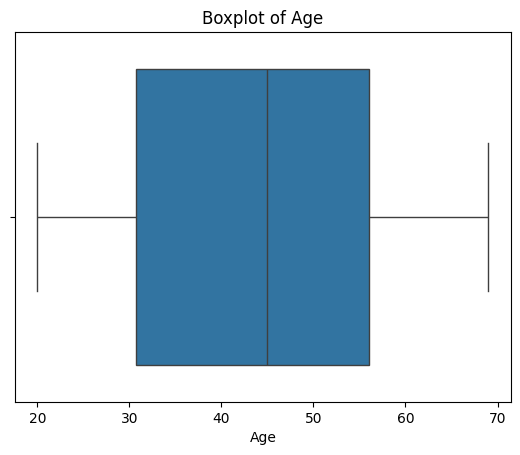

In [7]:
sns.boxplot(
    x=df['Age']
)

plt.title("Boxplot of Age")

plt.show()

In [8]:
#Skewness
print(
    "Skewness:",
    df['Age'].skew()
)

Skewness: 0.012141455267137275


## Normality Test

Using the **Shapiro-Wilk Test**

### Null Hypothesis

\[
H_0 : {Age follows normal distribution}
\]

### Alternative Hypothesis

\[
H_1 : {Age does not follow normal distribution}
\]

In [9]:
from scipy.stats import shapiro

stat, p = shapiro(df['Age'])

print("Shapiro Test Statistic:", stat)
print("P-value:", p)

Shapiro Test Statistic: 0.9488992946952997
P-value: 4.035055085974128e-12


In [10]:
if p > 0.05:
    print("Age is approximately normally distributed")
else:
    print("Age is not normally distributed")

Age is not normally distributed


2. What proportion of individuals are smokers vs non-smokers?




In [11]:
# Count smokers and non-smokers

smoking_counts = df['Smoking'].value_counts()

print(smoking_counts)

Smoking
No     293
Yes    207
Name: count, dtype: int64


In [12]:
# Percentage of smokers and non-smokers

smoking_percentage = (
    df['Smoking'].value_counts(normalize=True)
) * 100

print(smoking_percentage)

Smoking
No     58.6
Yes    41.4
Name: proportion, dtype: float64


3. Which income group has the highest frequency?

In [14]:
# Frequency of income groups

income_counts = df['Income'].value_counts()

print(income_counts)
# Most frequent income group

print(
    "Highest frequency income group is:",
    income_counts.idxmax()
)

Income
Low       204
Medium    197
High       99
Name: count, dtype: int64
Highest frequency income group is: Low


4. What percentage of individuals are exposed to high pollution?

In [15]:
# Percentage exposed to high pollution

high_pollution_percentage = (
    (df['Pollution'] == 'High').mean()
) * 100

print(
    "Percentage exposed to high pollution:",
    high_pollution_percentage
)

Percentage exposed to high pollution: 70.39999999999999


5. What is the overall prevalence of lung disease?

In [16]:
# Overall prevalence of lung disease

lung_disease_percentage = (
    (df['LungDisease'] == 'Yes').mean()
) * 100

print(
    "Overall prevalence of lung disease:",
    lung_disease_percentage
)

Overall prevalence of lung disease: 52.800000000000004


## Association & Crosstab

1. Is there an association between Smoking and Lung Disease?

In [17]:
# Contingency table

table = pd.crosstab(
    df['Smoking'],
    df['LungDisease']
)

print(table)

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


In [18]:
# Row percentage table

row_percent = pd.crosstab(
    df['Smoking'],
    df['LungDisease'],
    normalize='index'
) * 100

print(row_percent.round(2))

LungDisease     No    Yes
Smoking                  
No           62.80  37.20
Yes          25.12  74.88


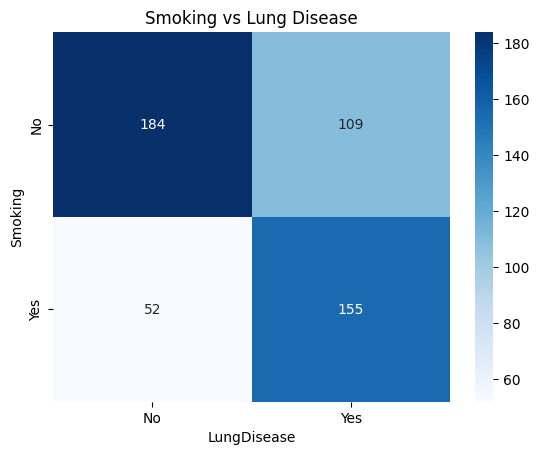

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Smoking vs Lung Disease"
)

plt.show()

**2. Interpret using a contingency table.**

###### Interpretation

The contingency table shows that smokers have a much higher proportion of lung disease compared to non-smokers.

Among smokers, approximately **74.88%** have lung disease, while only **37.20%** of non-smokers have lung disease.

This suggests a strong positive association between smoking and lung disease.

## Does Pollution Level Affect Lung Disease?

1. Compare lung disease prevalence across income groups.



In [23]:
# Income vs Lung Disease

income_table = pd.crosstab(
    df['Income'],
    df['LungDisease']
)

print(income_table)

LungDisease  No  Yes
Income              
High         51   48
Low          90  114
Medium       95  102


In [24]:
# Row percentage table

income_percent = pd.crosstab(
    df['Income'],
    df['LungDisease'],
    normalize='index'
) * 100

print(income_percent.round(2))

LungDisease     No    Yes
Income                   
High         51.52  48.48
Low          44.12  55.88
Medium       48.22  51.78


## Interpretation

The prevalence of lung disease varies across income groups.

Individuals in the **Low income** group have the highest prevalence of lung disease, with approximately **55.88%** affected.

The **Medium income** group has a lung disease prevalence of **51.78%**, while the **High income** group has the lowest prevalence at **48.48%**.

This suggests that lower income groups may be more affected by lung disease compared to higher income groups.

**2. Which factor appears to have the strongest relationship with lung disease?**

In [25]:
print("Smoking vs Lung Disease")
print(row_percent.round(2))

print("\nPollution vs Lung Disease")
print(pollution_percent.round(2))

print("\nIncome vs Lung Disease")
print(income_percent.round(2))

Smoking vs Lung Disease
LungDisease     No    Yes
Smoking                  
No           62.80  37.20
Yes          25.12  74.88

Pollution vs Lung Disease
LungDisease     No    Yes
Pollution                
High         38.64  61.36
Low          67.57  32.43

Income vs Lung Disease
LungDisease     No    Yes
Income                   
High         51.52  48.48
Low          44.12  55.88
Medium       48.22  51.78


## Interpretation

Among the examined factors, **Smoking** appears to have the strongest relationship with lung disease.

Approximately **74.88%** of smokers have lung disease compared to only **37.20%** of non-smokers, showing a large difference between groups.

Pollution also shows a noticeable association, as individuals exposed to high pollution have a higher prevalence of lung disease (**61.36%**) compared to those exposed to low pollution (**32.43%**).

Income shows comparatively smaller differences in lung disease prevalence across groups.

## Statistical Testing

1. Perform a Chi-square test for:
   - Smoking vs Lung Disease
   - Pollution vs Lung Disease

In [26]:
#Smoking vs Lung Disease — Chi-Square Test

from scipy.stats import chi2_contingency

# Contingency table

smoking_table = pd.crosstab(
    df['Smoking'],
    df['LungDisease']
)

print(smoking_table)

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


In [27]:
# Chi-square test

chi2, p, dof, expected = chi2_contingency(
    smoking_table
)

print("Chi-square Statistic:", chi2)

print("Degrees of Freedom:", dof)

print("P-value:", p)

Chi-square Statistic: 67.5942649754021
Degrees of Freedom: 1
P-value: 2.0085094601569646e-16


## Interpretation

The Chi-square test results indicate a statistically significant association between Smoking and Lung Disease.

Since the p-value is much smaller than 0.05, we reject the null hypothesis of independence.

This suggests that smoking status is significantly related to lung disease occurrence.

In [29]:
#Pollution vs Lung Disease — Chi-Square Test
# Contingency table

pollution_table = pd.crosstab(
    df['Pollution'],
    df['LungDisease']
)

print(pollution_table)

LungDisease   No  Yes
Pollution            
High         136  216
Low          100   48


In [30]:
# Chi-square test

chi2, p, dof, expected = chi2_contingency(
    pollution_table
)

print("Chi-square Statistic:", chi2)

print("Degrees of Freedom:", dof)

print("P-value:", p)

Chi-square Statistic: 33.84256825473482
Degrees of Freedom: 1
P-value: 5.975692575712951e-09


## Interpretation

The Chi-square test results show a statistically significant association between Pollution Level and Lung Disease.

Since the p-value is less than 0.05, we reject the null hypothesis of independence.

This suggests that pollution level is significantly related to the occurrence of lung disease.

**2. When Should Fisher’s Exact Test Be Used?**

Fisher’s Exact Test should be used instead of the Chi-square test
when sample size is small or when expected cell frequencies
are less than 5 in a contingency table.

**3. Odds Ratio for Smoking and Lung Disease**

In [31]:
print(smoking_table)

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


In [32]:
#Calculate Odds Ratio
from statsmodels.stats.contingency_tables import Table2x2

# Convert to numpy array

table_array = smoking_table.values

# Odds ratio

oddsratio = Table2x2(
    table_array
)

print(
    "Odds Ratio:",
    oddsratio.oddsratio
)

Odds Ratio: 5.031757233592096


## Interpretation

The odds ratio is approximately **5.03**, which indicates that smokers have about **5 times higher odds** of developing lung disease compared to non-smokers.

This suggests a strong positive association between smoking and lung disease.

## Correlation & Interpretation

1. Interpret the correlation between:
   - Smoking and Lung Disease
   - Age and Lung Disease



In [33]:
# Convert categorical variables to numeric

df['Smoking_num'] = df['Smoking'].map({
    'No': 0,
    'Yes': 1
})

df['LungDisease_num'] = df['LungDisease'].map({
    'No': 0,
    'Yes': 1
})

In [34]:
# Correlation between Smoking and Lung Disease

correlation_smoking = df[
    ['Smoking_num', 'LungDisease_num']
].corr()

print(correlation_smoking)

                 Smoking_num  LungDisease_num
Smoking_num         1.000000         0.371747
LungDisease_num     0.371747         1.000000


## Interpretation

The correlation coefficient between Smoking and Lung Disease is **0.372**, indicating a moderate positive relationship.

This suggests that individuals who smoke are more likely to develop lung disease compared to non-smokers.

**2. Why is correlation not sufficient for causal inference?**


Correlation is not sufficient for causal inference because correlation only measures the strength and direction of association between variables.

A correlation between two variables does not necessarily mean that one variable causes the other.

Other factors, called confounding variables, may influence both variables simultaneously. In addition, correlation cannot establish temporal order or rule out coincidence.

Therefore, further statistical analysis and experimental or longitudinal studies are needed to establish causation.

## Logistic Regression

1. Fit a logistic regression model:

\[
{LungDisease} ~ {Smoking} + {Age} + \{Pollution} + {Income}
\]

2. Which variables are statistically significant predictors?

3. Interpret the odds ratio of Smoking.

4. What happens to the effect of Smoking after adjusting for Pollution?

1. Fit a logistic regression model:

\[
{LungDisease} ~ {Smoking} + {Age} + \{Pollution} + {Income}
\]

In [35]:
import statsmodels.formula.api as smf

In [36]:
# Fit logistic regression model

model = smf.logit(
    'LungDisease_num ~ Smoking_num + Age + C(Pollution) + C(Income)',
    data=df
).fit()

Optimization terminated successfully.
         Current function value: 0.552949
         Iterations 6


In [37]:
# View model summary

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:                            5
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.2005
Time:                        09:35:59   Log-Likelihood:                -276.47
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 3.499e-28
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.1940      0.425     -5.164      0.000      -3.027      -1.361
C(Pollution)[T.Low]    -1.3027      0.235     -5.533      0.000      -1.764      -0.841
C(Income)[T.Low]

## Interpretation

The logistic regression model is statistically significant, indicating that the predictors collectively explain lung disease occurrence.

### Significant Predictors

- **Smoking** is a statistically significant predictor of lung disease (\(p < 0.001\)).
- **Age** is also statistically significant (\(p < 0.001\)).
- **Pollution level** significantly affects lung disease (\(p < 0.001\)).

### Income

The income variables are not statistically significant because their p-values are greater than 0.05.

### Smoking Effect

The positive coefficient for Smoking indicates that smokers have a higher probability of developing lung disease compared to non-smokers.

### Age Effect

The positive coefficient for Age suggests that the probability of lung disease increases with age.

### Pollution Effect

Individuals exposed to low pollution have lower odds of lung disease compared to those exposed to high pollution.

2. Which variables are statistically significant predictors?

In [38]:
# Extract p-values

print(model.pvalues)

Intercept              2.413178e-07
C(Pollution)[T.Low]    3.139044e-08
C(Income)[T.Low]       1.226431e-01
C(Income)[T.Medium]    4.397235e-01
Smoking_num            6.131827e-15
Age                    4.906629e-08
dtype: float64


## Interpretation

The statistically significant predictors of lung disease are:

- **Smoking** (\(p < 0.001\))
- **Age** (\(p < 0.001\))
- **Pollution** (\(p < 0.001\))

These variables have p-values less than 0.05, indicating a significant association with lung disease.

The income variables are not statistically significant because their p-values are greater than 0.05.

3. Interpret the Odds Ratio of Smoking

In [39]:
import numpy as np

# Odds ratios

odds_ratios = np.exp(
    model.params
)

print(odds_ratios)

Intercept              0.111471
C(Pollution)[T.Low]    0.271784
C(Income)[T.Low]       1.552101
C(Income)[T.Medium]    1.246243
Smoking_num            5.485739
Age                    1.040683
dtype: float64


In [40]:
print(
    "Odds Ratio of Smoking:",
    odds_ratios['Smoking_num']
)

Odds Ratio of Smoking: 5.485738801540751


## Interpretation

The odds ratio for Smoking is approximately **5.49**.

This indicates that smokers have about **5.5 times higher odds** of developing lung disease compared to non-smokers, after adjusting for age, pollution, and income.

4. What happens to the effect of Smoking after adjusting for Pollution?

In [41]:
# Logistic regression without Pollution

model_without_pollution = smf.logit(
    'LungDisease_num ~ Smoking_num + Age + C(Income)',
    data=df
).fit()

print(model_without_pollution.summary())

Optimization terminated successfully.
         Current function value: 0.585871
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            4
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.1528
Time:                        09:41:00   Log-Likelihood:                -292.94
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 5.986e-22
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.5652      0.418     -6.138      0.000      -3.384      -1.746
C(

In [42]:
print(
    "Smoking coefficient without Pollution:",
    model_without_pollution.params['Smoking_num']
)

print(
    "Smoking coefficient with Pollution:",
    model.params['Smoking_num']
)

Smoking coefficient without Pollution: 1.6651027434859365
Smoking coefficient with Pollution: 1.7021517795592478


In [43]:
# Odds ratios

or_without_pollution = np.exp(
    model_without_pollution.params['Smoking_num']
)

or_with_pollution = np.exp(
    model.params['Smoking_num']
)

print(
    "Odds Ratio without Pollution:",
    or_without_pollution
)

print(
    "Odds Ratio with Pollution:",
    or_with_pollution
)

Odds Ratio without Pollution: 5.286216346155295
Odds Ratio with Pollution: 5.485738801540751


## Interpretation

The effect of Smoking remains strong even after adjusting for Pollution.

The smoking coefficient and odds ratio changed only slightly after including pollution in the model:

- Odds Ratio without Pollution = **5.29**
- Odds Ratio with Pollution = **5.49**

This suggests that smoking independently contributes to lung disease risk, and its effect is not fully explained by pollution exposure.

## Advanced Modeling

1. Add an interaction term:

\[
{Smoking} X {Pollution}
\]

2. Is the interaction significant?

3. Interpret the interaction.

4. Does pollution amplify smoking risk?

1. Add an interaction term:

\[
{Smoking} X {Pollution}
\]

In [45]:
# Logistic regression with interaction term

interaction_model = smf.logit(
    'LungDisease_num ~ Smoking_num * C(Pollution) + Age + C(Income)',
    data=df
).fit()
print(interaction_model.summary())

Optimization terminated successfully.
         Current function value: 0.552178
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      493
Method:                           MLE   Df Model:                            6
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.2016
Time:                        09:44:44   Log-Likelihood:                -276.09
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 1.341e-27
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -2.1285      0.430     -4.953  

## 2. Is the interaction significant?

The interaction term between Smoking and Pollution is not statistically significant because:

\[
p = 0.382 > 0.05
\]

This indicates that there is insufficient evidence of a significant interaction effect between smoking and pollution on lung disease risk.

## 3. Interpret the interaction

The positive interaction coefficient suggests that the combined effect of smoking and pollution may increase lung disease risk more than their individual effects alone.

However, since the interaction term is not statistically significant, this additional combined effect is not strong enough to conclude a meaningful interaction in the population.

## 4. Does pollution amplify smoking risk?

The interaction coefficient is positive, which suggests that pollution may increase the effect of smoking on lung disease risk.

However, because the interaction term is not statistically significant (\(p > 0.05\)), there is no strong statistical evidence that pollution significantly amplifies smoking risk.

## Model Evaluation

1. Compute the ROC curve and AUC.

2. Is the model good?

3. What is the confusion matrix?

4. Discuss model accuracy vs sensitivity vs specificity.

1. Compute the ROC curve and AUC.

In [46]:
# Predicted probabilities

y_pred_prob = model.predict(df)

In [47]:
#ROC curve and AUC
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# ROC components

fpr, tpr, thresholds = roc_curve(
    df['LungDisease_num'],
    y_pred_prob
)

# AUC score

auc = roc_auc_score(
    df['LungDisease_num'],
    y_pred_prob
)

print("AUC:", auc)

AUC: 0.7871645480225988


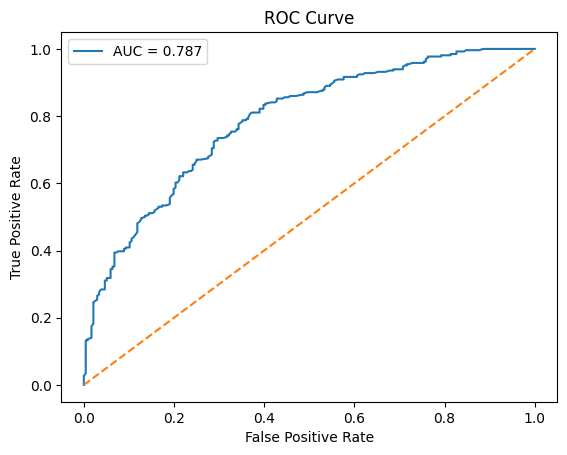

In [48]:
import matplotlib.pyplot as plt

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

2. Is the model good?

## Interpretation

The model appears to be reasonably good because the AUC value is approximately **0.787**.

An AUC between **0.7 and 0.8** indicates **acceptable discrimination ability**, meaning the model can fairly well distinguish between individuals with and without lung disease.

Therefore, the logistic regression model has a good predictive performance, although there is still room for improvement.

3. What is the confusion matrix?

In [49]:
# Predicted classes

y_pred_class = (
    y_pred_prob >= 0.5
).astype(int)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df['LungDisease_num'],
    y_pred_class
)

print(cm)

[[156  80]
 [ 64 200]]


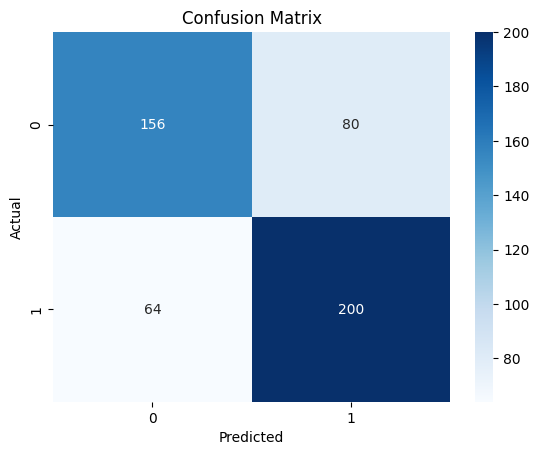

In [50]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Interpretation of Confusion Matrix

The confusion matrix shows that:

- **156** individuals without lung disease were correctly classified (**True Negatives**).
- **200** individuals with lung disease were correctly classified (**True Positives**).
- **80** individuals without lung disease were incorrectly classified as having lung disease (**False Positives**).
- **64** individuals with lung disease were incorrectly classified as not having lung disease (**False Negatives**).

Overall, the model correctly classifies a large number of cases, indicating reasonably good predictive performance.

4. Discuss model accuracy vs sensitivity vs specificity.

In [51]:
from sklearn.metrics import (
    accuracy_score,
    recall_score
)

# Accuracy

accuracy = accuracy_score(
    df['LungDisease_num'],
    y_pred_class
)

# Sensitivity (Recall)

sensitivity = recall_score(
    df['LungDisease_num'],
    y_pred_class
)

# Specificity

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

print("Accuracy:", accuracy)

print("Sensitivity:", sensitivity)

print("Specificity:", specificity)

Accuracy: 0.712
Sensitivity: 0.7575757575757576
Specificity: 0.6610169491525424


## Interpretation

The model achieved an accuracy of approximately **71.2%**, meaning that about 71% of the observations were correctly classified.

The sensitivity is approximately **75.8%**, indicating that the model is fairly good at correctly identifying individuals with lung disease.

The specificity is approximately **66.1%**, meaning the model is moderately effective at correctly identifying individuals without lung disease.

Overall, the model performs reasonably well, with better sensitivity than specificity, suggesting it is more effective at detecting lung disease cases than non-disease cases.

## Research Question

> “Using the lung disease dataset, perform exploratory data analysis and fit a logistic regression model to identify key determinants of lung disease. Interpret your findings and discuss public health implications.”

# Research Question

## Exploratory Data Analysis and Logistic Regression Findings

Exploratory data analysis showed noticeable differences in lung disease prevalence across smoking status, pollution exposure, and income groups.

Smokers had a substantially higher prevalence of lung disease compared to non-smokers. Individuals exposed to high pollution also showed a higher proportion of lung disease cases. Lower income groups appeared to have slightly higher lung disease prevalence than higher income groups.

Chi-square tests indicated statistically significant associations between:
- Smoking and Lung Disease
- Pollution and Lung Disease

The odds ratio analysis showed that smokers had approximately **5 times higher odds** of developing lung disease compared to non-smokers.

A logistic regression model was fitted using Smoking, Age, Pollution, and Income as predictors of lung disease.

The model identified:
- Smoking
- Age
- Pollution

as statistically significant predictors of lung disease, while income variables were not statistically significant after adjustment.

The logistic regression results indicated that:
- smokers had significantly higher odds of lung disease,
- increasing age was associated with higher lung disease risk,
- and exposure to high pollution increased the likelihood of lung disease.

The interaction analysis between Smoking and Pollution suggested a positive interaction effect, although the interaction term was not statistically significant.

Model evaluation showed:
- AUC ≈ 0.787
- Accuracy ≈ 71.2%
- Sensitivity ≈ 75.8%
- Specificity ≈ 66.1%

These results indicate that the model has acceptable predictive performance and is reasonably effective at identifying individuals with lung disease.

## Public Health Implications

The findings highlight smoking and pollution exposure as major risk factors for lung disease.

Public health interventions should focus on:
- reducing smoking prevalence,
- improving air quality,
- increasing awareness regarding respiratory health,
- and promoting early screening for high-risk populations.

Policies targeting smoking cessation and environmental pollution control may substantially reduce the burden of lung disease in the population.